# 03. Feature Analysis
Given a specific modeling approach, attempt to determine which features are attended for classification results. Additionally, attempt to obtain Shapley values for the features and present on a figure.

In [1]:
import os
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn import svm
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

data_df = None
if os.path.isfile("data/data.pkl"):
    data_df = pd.read_pickle("data/data.pkl")
else:
    print("Load Data")
data_df.head()

/home/km/Documents/Local/Files/Academic/Research/BrainConnectivity/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Subject_ID,Diagnosis,Study,Data,Connectome,EVC,CLU,DIV
0,1144,HC,MUSC,"[[58.73076183, 136.138853, 71.32999539, 41.065...","[[0.0, -0.14159653131781452, -0.01696992835995...","[0.00882765564582845, 0.012992044516828722, 0....","[0.006690112258848986, 0.00677957588786147, 0....","[0.9874632735385, 0.9796586961296364, 0.964520..."
1,1104,HC,MUSC,"[[12.18384103, -31.72224568, 11.98897454, 2.31...","[[0.0, -0.05963586996156045, -0.00447346309142...","[0.0030474747387929666, 0.027722135075707012, ...","[0.009840366701664785, 0.011338349699506192, 0...","[0.9619945142677632, 0.9612533230954341, 0.975..."
2,1085,HC,MUSC,"[[-1.300582984, -6.808979653, -28.1579185, 7.3...","[[0.0, -0.2652810998939504, 0.0209836959172419...","[0.036331611587248874, 0.025120921603343362, 0...","[0.014165572069570698, 0.013515561660305219, 0...","[0.9800037416273699, 0.9761500612391321, 0.969..."
3,1051,HC,MUSC,"[[23.00822698, -126.074722, 77.52625116, 17.74...","[[0.0, -0.05925102455996451, -0.03625953478906...","[0.00791636744924377, 0.03611860964572453, 0.0...","[0.012860192895338064, 0.012706715663247686, 0...","[0.9669454007797847, 0.97436119789489, 0.96890..."
4,1155,HC,MUSC,"[[-6.295390793, -24.09210886, 31.53133265, -28...","[[0.0, -0.037840818730998683, -0.0440939570337...","[0.017409557893134447, 0.010886255401032623, 0...","[0.010173478405801618, 0.010274142338296474, 0...","[0.9544663828468297, 0.9249482579239692, 0.952..."


In [2]:
tbi_df = data_df[data_df["Study"] == "TBI"]
tbi_evc = np.vstack(tbi_df["EVC"])
tbi_class = np.where(tbi_df["Diagnosis"] == "POS", 1, 0)

In [3]:
state = 100

clf = svm.SVC(
    kernel="sigmoid",
    class_weight="balanced",
    probability=True,
    random_state=state
)

scaler = StandardScaler()
tbi_evc_scaled = scaler.fit_transform(tbi_evc)

x_train, x_test, y_train, y_test = train_test_split(tbi_evc_scaled, 
                                                    tbi_class, 
                                                    random_state=state, 
                                                    stratify=tbi_class)
feature_variance = pd.DataFrame(x_train).var(axis=0)
print("Feature Variance:\n", feature_variance)
clf.fit(x_train, y_train)
# best_model = clf

Feature Variance:
 0      0.958429
1      0.248323
2      1.178327
3      1.091281
4      1.078503
         ...   
248    1.166906
249    1.118243
250    1.164502
251    1.078830
252    1.156026
Length: 253, dtype: float64


SVC(class_weight='balanced', kernel='sigmoid', probability=True,
    random_state=100)

In [4]:

svc_params = {
        'C': np.linspace(0.1, 10, 25),
        'kernel': ['linear', 'rbf', 'sigmoid'],
        'gamma': np.logspace(1e-10, 1, 10),
    }

gridsearch = GridSearchCV(estimator=clf,
                          param_grid=svc_params,
                          cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=state),
                          refit=True)
gridsearch.fit(x_train, y_train)
best_model = gridsearch.best_estimator_

KeyboardInterrupt: 

In [95]:
explainer = shap.KernelExplainer(best_model.predict_proba, x_train)
shap_values = explainer.shap_values(x_test)
shap_pos_class = shap_values[:,:,1]
shap_values_pos = shap.Explanation(
    values=shap_pos_class,
    base_values=explainer.expected_value[1],
    data=x_test,
    feature_names=[f"Feature {i+1}" for i in range(x_test.shape[1])]
)

Using 141 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 26/26 [02:32<00:00,  5.87s/it]


Best Model Parameters: {'C': np.float64(0.925), 'gamma': np.float64(1.0000000002302585), 'kernel': 'rbf'}
              precision    recall  f1-score   support

           0       0.57      0.50      0.53        16
           1       0.33      0.40      0.36        10

    accuracy                           0.46        26
   macro avg       0.45      0.45      0.45        26
weighted avg       0.48      0.46      0.47        26

Confusion Matrix:
 [[8 8]
 [6 4]]
Feature Importances:
 [ 7.69230769e-03  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  1.11022302e-17
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -7.69230769e-03  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00 -7.69230769e-03  0.00000000e+00
  7.69230769e-03  0.00000000e+00  0.00000000e+00  0.00000000e+00
  7.69230769e-03  1.11022302e-17 -7.69230769e-03  0.0000

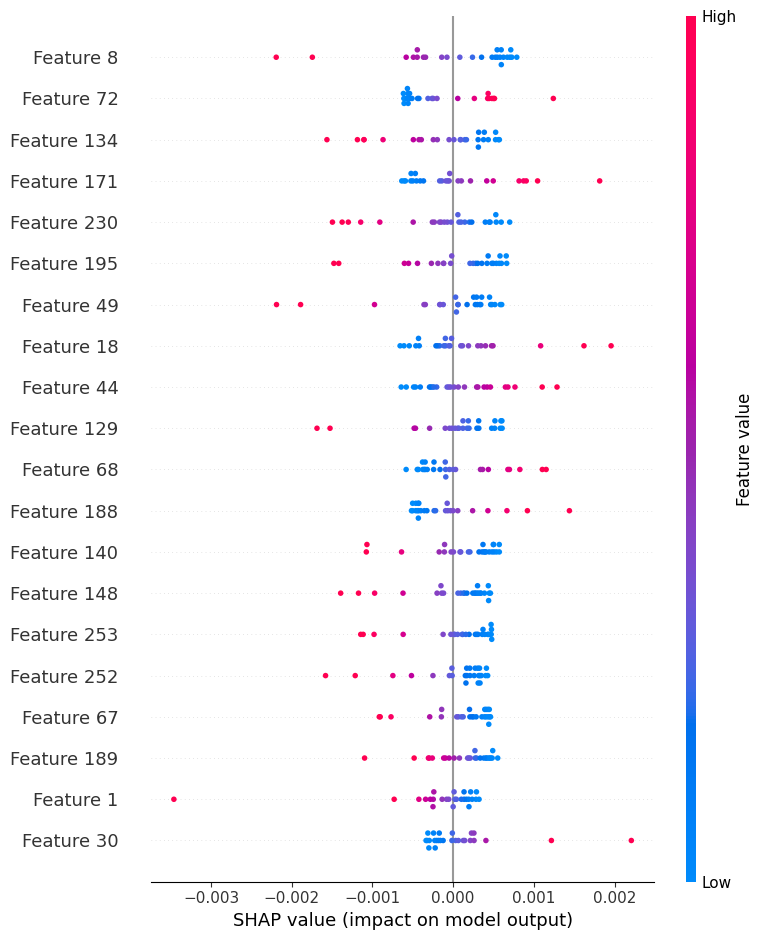

In [ ]:
print("Best Model Parameters:", gridsearch.best_params_)

y_predict = best_model.predict(x_test)
print(classification_report(y_test, y_predict))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict))

importances = permutation_importance(best_model, x_test, y_test, scoring="accuracy")
print("Feature Importances:\n", importances.importances_mean)

shap.summary_plot(shap_pos_class, x_test, feature_names=[f"Feature {i+1}" for i in range(x_test.shape[1])])

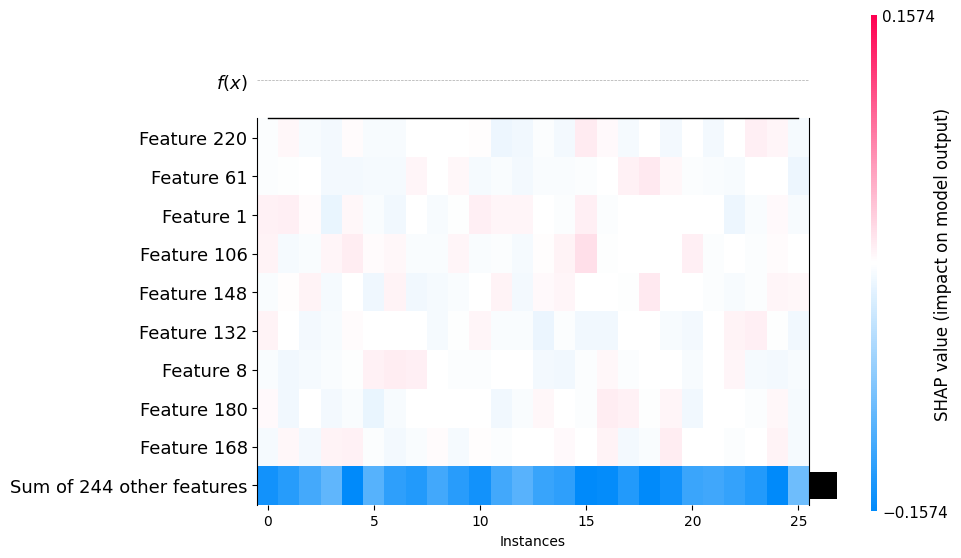

<Axes: xlabel='Instances'>

In [ ]:
shap.plots.heatmap(shap_values_pos)

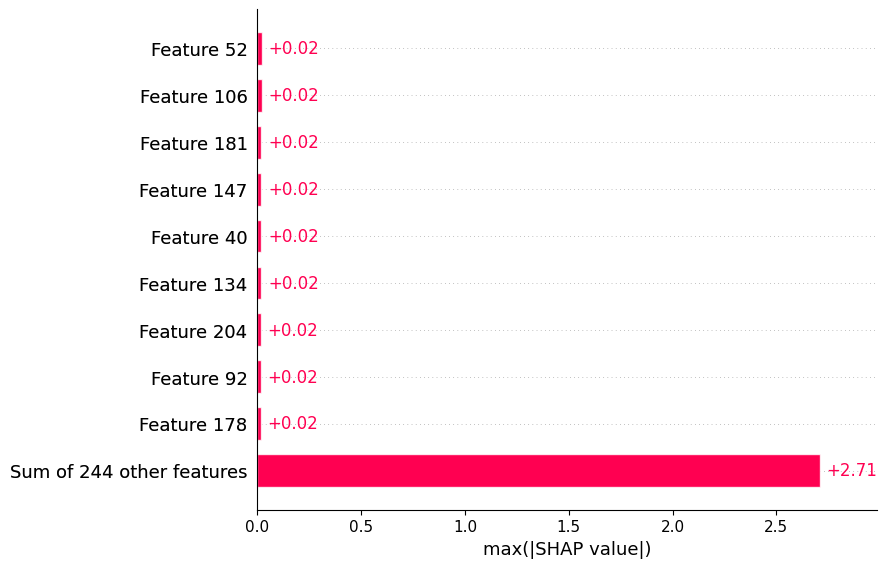

In [ ]:
shap.plots.bar(shap_values_pos.abs.max(0))

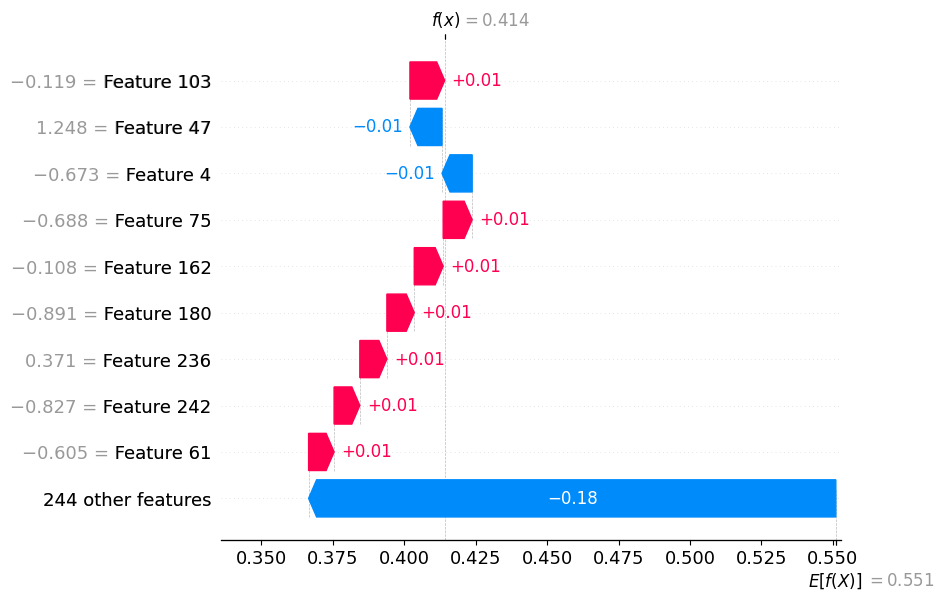

In [ ]:
# Waterfall plots display individual predictions, so they expect a single row 
# of an Explanation object as input
sample_ind = 0 
shap.waterfall_plot(shap.Explanation(values=shap_pos_class[sample_ind],
                                     base_values=explainer.expected_value[1],
                                     data=x_test[sample_ind],
                                     feature_names=[f"Feature {i+1}" for i in range(x_test.shape[1])]))


### LASSO

In [87]:
from sklearn.linear_model import Lasso, lasso_path, LassoCV
from sklearn.metrics import mean_squared_error

reg = Lasso(alpha=1)
reg.fit(x_train, y_train)
print('R squared training set', round(reg.score(x_train, y_train)*100, 2))
print('R squared test set', round(reg.score(x_test, y_test)*100, 2))

# Training data
pred_train = reg.predict(x_train)
mse_train = mean_squared_error(y_train, pred_train)
print('MSE training set', round(mse_train, 2))

# Test data
pred = reg.predict(x_test)
mse_test = mean_squared_error(y_test, pred)
print('MSE test set', round(mse_test, 2))

R squared training set 0.0
R squared test set -0.01
MSE training set 0.24
MSE test set 0.24


Computing regularization path using the lasso...
Best alpha: 0.07998957260017699
R squared training set 10.79
R squared test set 2.33
MSE test: 0.2311640117762595


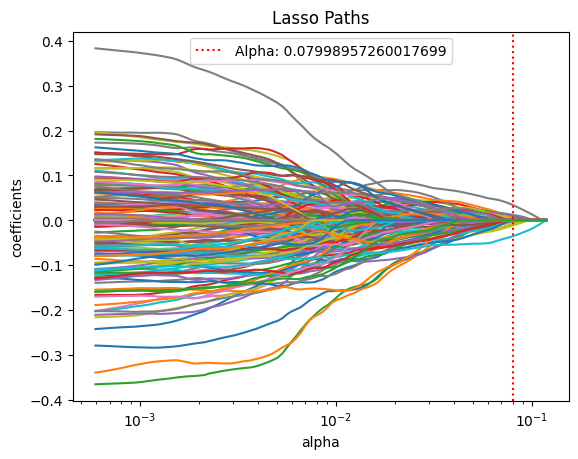

In [ ]:
print("Computing regularization path using the lasso...")
eps = 5e-3
alphas_lasso, coefs_lasso, _ = lasso_path(x_train, y_train, eps=eps)

plt.figure(1)
for coef_lasso in coefs_lasso:
    l1 = plt.semilogx(alphas_lasso, coef_lasso)

plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.title("Lasso Paths")
plt.axis("tight")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=state)
lasso_cv = LassoCV(cv=skf, random_state=state, max_iter=10000)
lasso_cv.fit(x_train, y_train)
best_alpha = lasso_cv.alpha_
print(f"Best alpha: {best_alpha}")

plt.axvline(x=best_alpha, color='red', linestyle='dotted', label=f"Alpha: {best_alpha}")

lasso_best = Lasso(alpha=best_alpha)
lasso_best.fit(x_train, y_train)
coefficients = lasso_best.coef_
nonzero_indices = np.where(coefficients != 0)[0]

sorted_data = sorted(
    [(idx + 1, coef) for idx, coef in zip(nonzero_indices, coefficients[nonzero_indices])],
    key=lambda x: abs(x[1]), 
    reverse=True
)
coefficients_df = pd.DataFrame(sorted_data, columns=["Feature Index", "Coefficient"])

print('R squared training set', round(lasso_best.score(x_train, y_train)*100, 2))
print('R squared test set', round(lasso_best.score(x_test, y_test)*100, 2))
print('MSE test:', mean_squared_error(y_test, lasso_best.predict(x_test)))

plt.legend()
plt.show()


(np.float64(8.606995147031415e-05),
 np.float64(0.17173213061991838),
 np.float64(0.18732944464896556),
 np.float64(0.8423896608107643))

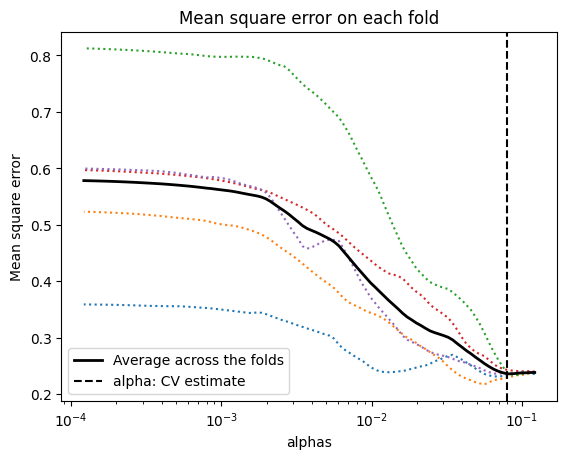

In [89]:
plt.semilogx(lasso_cv.alphas_, lasso_cv.mse_path_, ":")
plt.plot(
    lasso_cv.alphas_ ,
    lasso_cv.mse_path_.mean(axis=-1),
    "k",
    label="Average across the folds",
    linewidth=2,
)
plt.axvline(
    lasso_cv.alpha_, linestyle="--", color="k", label="alpha: CV estimate"
)

plt.legend()
plt.xlabel("alphas")
plt.ylabel("Mean square error")
plt.title("Mean square error on each fold")
plt.axis("tight")

# ymin, ymax = 50000, 250000
# plt.ylim(ymin, ymax);

In [90]:
coefficients_df

,Feature Index,Coefficient
0,18,0.0419924338
1,230,-0.0271430799
2,129,-0.0201363997
3,44,0.0124428992
4,8,-0.0109272439
5,49,-0.0093861024
6,140,-0.0074656948
7,115,0.0054744482
8,234,-0.0019755115
9,73,0.0010971126


In [91]:
from sklearn.feature_selection import f_regression
f_stat, p_values = f_regression(tbi_evc_scaled, tbi_class)
feature_data = pd.DataFrame({
    "Feature Index": range(1, len(p_values) + 1),
    "P-Value": p_values
})

significant_features = feature_data[feature_data["P-Value"] < 0.05].sort_values(by="P-Value")
significant_features

,Feature Index,P-Value
229,230,0.0035569710
48,49,0.0084918329
128,129,0.0085503487
17,18,0.0086613491
114,115,0.0122448169
252,253,0.0307039970
43,44,0.0368942499
66,67,0.0384283893
248,249,0.0448329592
247,248,0.0464225601


In [52]:
# from pygam import LogisticGAM, s
# import scipy.sparse

# def to_array(self):
#     return self.toarray()

# scipy.sparse.spmatrix.A = property(to_array)

# np.int = np.int32
# np.float = np.float64
# np.bool = np.bool_
# x_t = pd.DataFrame(x_train)
# print(x_t)
# gam = LogisticGAM(verbose=True).fit(x_t, y_train)
# gam.summary()

         0         1         2         3         4         5         6    \
0  -0.589766 -0.972544 -0.249103  0.089209 -0.587058 -0.252610 -0.916184   
1  -0.109172 -0.490633 -0.463193  0.264354 -0.341210  3.907517 -1.033636   
2  -0.385479 -0.802373  0.244362 -0.089532 -0.451427  0.056704  0.693678   
3   0.259838 -0.586714  1.573690 -0.616381 -0.736247 -0.365422 -0.022866   
4  -0.035679 -0.529264 -0.489966 -0.521108 -0.543348  1.284222 -0.917862   
..       ...       ...       ...       ...       ...       ...       ...   
60  0.478007 -0.205015  0.970066  0.103611 -0.253496  4.776642 -0.356632   
61 -0.551071  0.843995  0.069918 -0.351567 -0.527336  0.050702 -0.260151   
62 -0.028867 -0.582018 -0.770461 -0.571639 -0.630054  1.444572 -0.722985   
63 -0.642577 -0.172884 -0.687706 -0.608928 -0.081592 -0.681983 -0.210022   
64  0.316104  0.163465 -0.678661 -0.572019 -0.606959  0.190919 -0.976302   

         7         8         9    ...       243       244       245       246  \
0  -0.

/home/km/Documents/Local/Files/Academic/Research/BrainConnectivity/.venv/lib/python3.13/site-packages/pygam/utils.py:78: UserWarning: Could not import Scikit-Sparse or Suite-Sparse.
This will slow down optimization for models with monotonicity/convexity penalties and many splines.
See installation instructions for installing Scikit-Sparse and Suite-Sparse via Conda.
  warnings.warn(msg)


LinAlgError: SVD did not converge

In [53]:
# gam_opt = LogisticGAM().gridsearch(x_train, y_train)
# gam_opt.summary()

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:01:37 ETA:   0:16:15
 18% (2 of 11) |####                     | Elapsed Time: 0:03:06 ETA:   0:13:58
 27% (3 of 11) |######                   | Elapsed Time: 0:04:34 ETA:   0:12:12
 36% (4 of 11) |#########                | Elapsed Time: 0:06:05 ETA:   0:10:38


KeyboardInterrupt: 

In [ ]:
# pd.set_option('display.float_format', '{:.10f}'.format)
# feature_data.to_csv('out.csv')